In [1]:
#importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from sklearn import metrics


In [2]:
#loading the data
car_data=pd.read_csv("car data.csv")
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
car_data.shape

(301, 9)

In [4]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
car_data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [6]:
print(car_data.Fuel_Type.value_counts())
print(car_data.Seller_Type.value_counts())
print(car_data.Transmission.value_counts())



Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


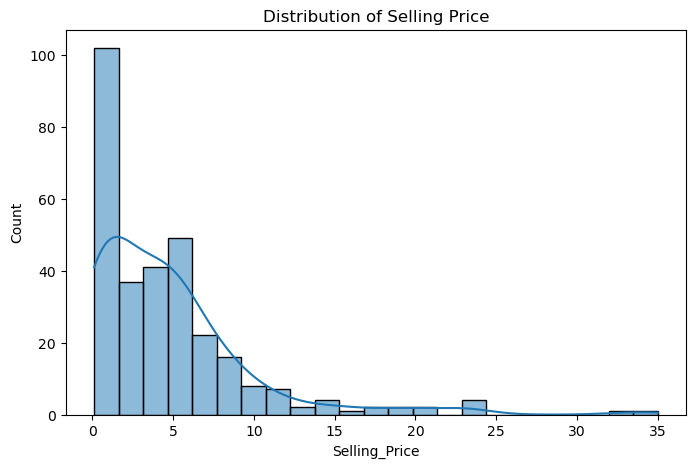

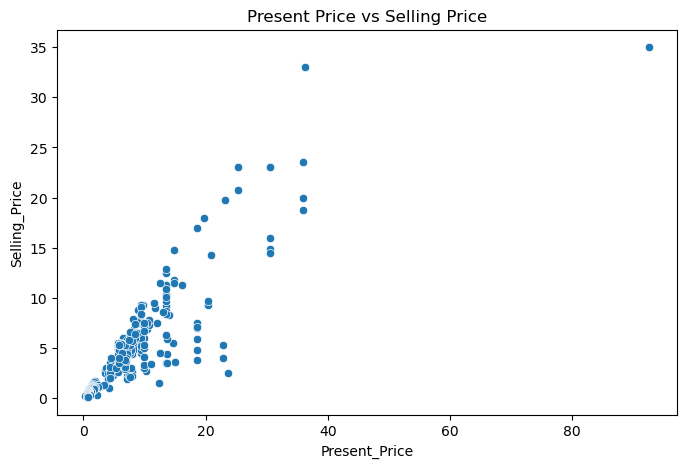

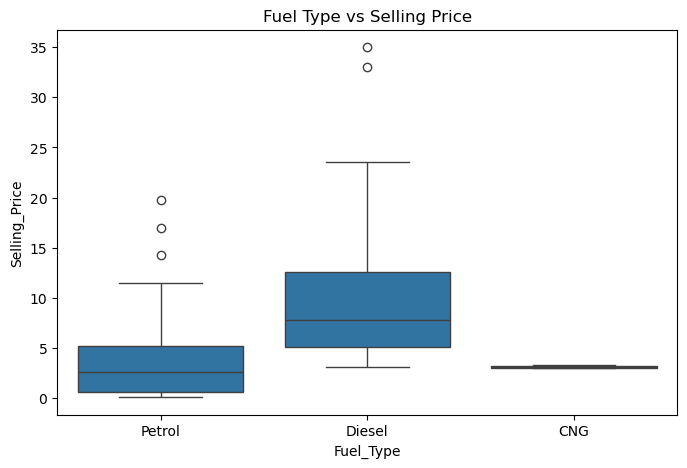

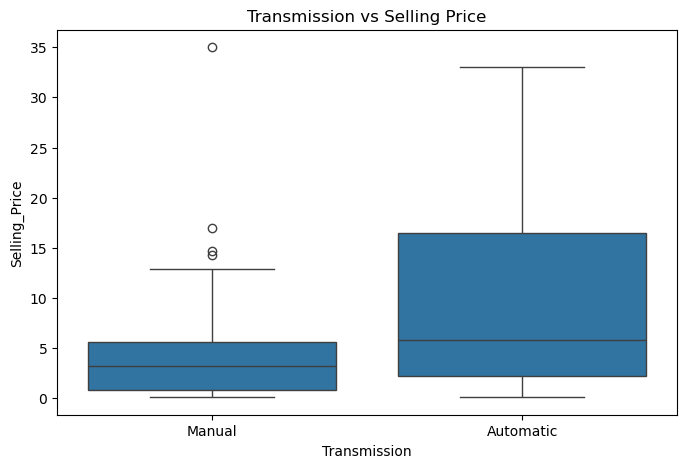

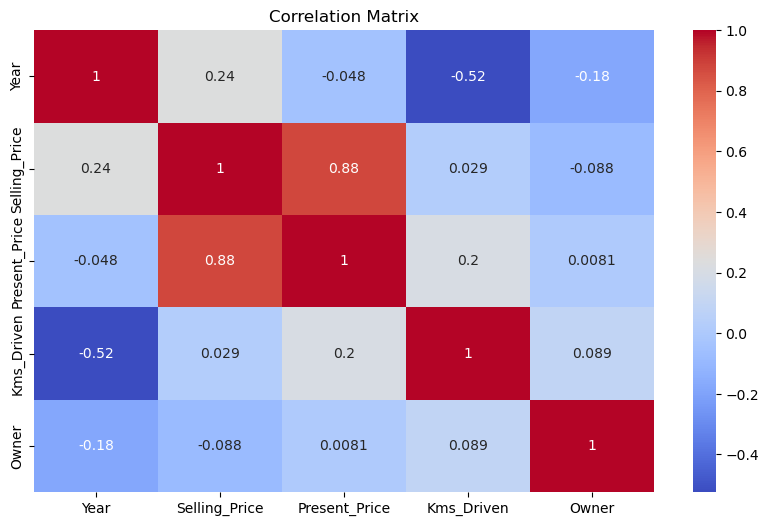

In [7]:
#visualisation

#graph of selling price distribution
plt.figure(figsize=(8,5))
sns.histplot(car_data['Selling_Price'],kde=True)
plt.title("Distribution of Selling Price")
plt.show()

#graph of present price vs selling price
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Present_Price',
    y='Selling_Price',
    data=car_data
)
plt.title("Present Price vs Selling Price")
plt.show()

#graph of fuel type vs selling price
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Fuel_Type',
    y='Selling_Price',
    data=car_data
)
plt.title("Fuel Type vs Selling Price")
plt.show()

#graph of transmission vs selling price
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Transmission',
    y='Selling_Price',
    data=car_data
)
plt.title("Transmission vs Selling Price")
plt.show()

#graph of correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    car_data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

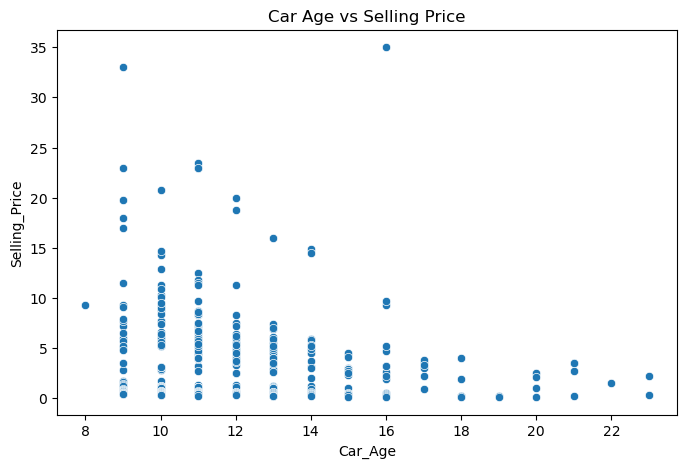

In [8]:
#feature engineering
car_data['Car_Age'] = 2026 - car_data['Year']
car_data.drop('Year', axis=1, inplace=True)
car_data[['Car_Age','Selling_Price']].corr()
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Car_Age',
    y='Selling_Price',
    data=car_data
)
plt.title("Car Age vs Selling Price")
plt.show()

In [9]:
#encoding
car_data=pd.get_dummies(car_data, columns=['Fuel_Type'], drop_first=True)
car_data.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
car_data.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

C:\Users\grees\AppData\Local\Temp\ipykernel_31552\2016028779.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_data.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
C:\Users\grees\AppData\Local\Temp\ipykernel_31552\2016028779.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_data.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)


In [10]:
car_data.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Seller_Type,Transmission,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol
0,ritz,3.35,5.59,27000,0,0,0,12,False,True
1,sx4,4.75,9.54,43000,0,0,0,13,True,False
2,ciaz,7.25,9.85,6900,0,0,0,9,False,True
3,wagon r,2.85,4.15,5200,0,0,0,15,False,True
4,swift,4.60,6.87,42450,0,0,0,12,True,False


In [11]:

X=car_data.drop(['Car_Name','Selling_Price'],axis=1)
y=car_data['Selling_Price']


In [12]:
print(X)

     Present_Price  Kms_Driven  Seller_Type  Transmission  Owner  Car_Age  \
0             5.59       27000            0             0      0       12   
1             9.54       43000            0             0      0       13   
2             9.85        6900            0             0      0        9   
3             4.15        5200            0             0      0       15   
4             6.87       42450            0             0      0       12   
..             ...         ...          ...           ...    ...      ...   
296          11.60       33988            0             0      0       10   
297           5.90       60000            0             0      0       11   
298          11.00       87934            0             0      0       17   
299          12.50        9000            0             0      0        9   
300           5.90        5464            0             0      0       10   

     Fuel_Type_Diesel  Fuel_Type_Petrol  
0               False            

In [13]:
print(y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=2)

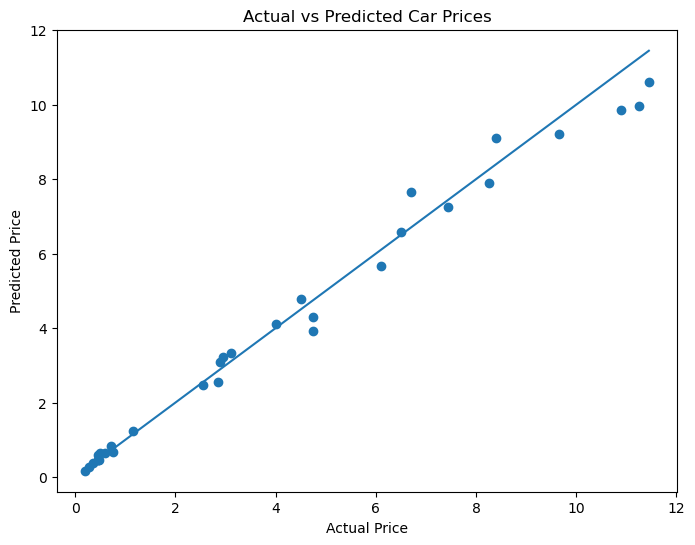

In [15]:
#linear regression
model=LinearRegression()
model.fit(X_train,y_train)
predict=model.predict(X_train)

#random forest regression
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

#graph of actual and predicted prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)]
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [16]:
#finding r2 score ogf linear regression
test_prediction=model.predict(X_test)
lr_score = r2_score(y_test, test_prediction)
print("Linear Regression R²:", lr_score)

#finding r2 score of random forest regressor
rf_score = r2_score(y_test, rf_pred)
print("Random Forest R²:", rf_score)

Linear Regression R²: 0.8693753727249809
Random Forest R²: 0.9833965783216644


In [17]:
#MAE,RMSE,R2
lr_mae = mean_absolute_error(y_test, test_prediction)
lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_prediction
    )
)

print("LR MAE:", lr_mae)
print("LR RMSE:", lr_rmse)


rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)
print("RF MAE:", rf_mae)
print("RF RMSE:", rf_rmse)

LR MAE: 1.0725913724011034
LR RMSE: 1.3109552209419701
RF MAE: 0.3175225806451612
RF RMSE: 0.46738430481467536


In [18]:
#model comparison
comparison = pd.DataFrame({
    "Model": ["Linear Regression",
              "Random Forest"],
    "R2 Score": [lr_score,
                 rf_score],
    "MAE": [lr_mae,
            rf_mae],
    "RMSE": [lr_rmse,
             rf_rmse]
})

print(comparison)

               Model  R2 Score       MAE      RMSE
0  Linear Regression  0.869375  1.072591  1.310955
1      Random Forest  0.983397  0.317523  0.467384


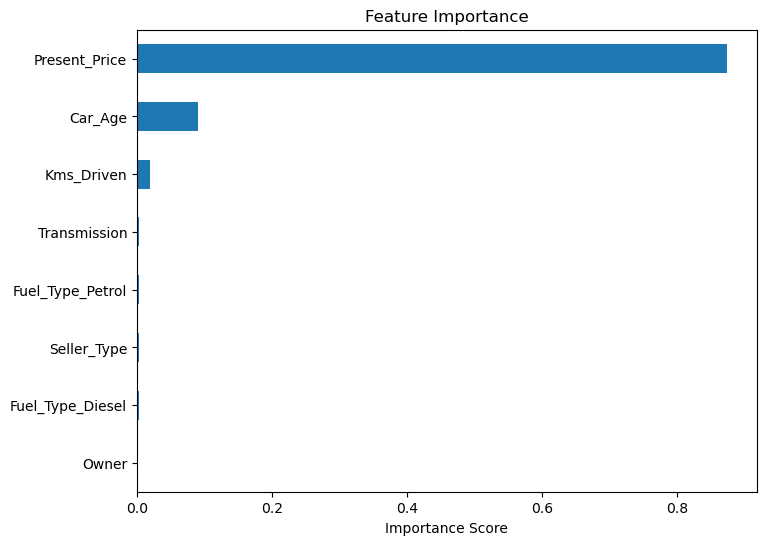

In [19]:
#finding feature importance
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)


feature_importance.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [20]:
#predicting the selling price of a car
sample = pd.DataFrame([{
    'Present_Price': 6.0,
    'Kms_Driven': 40000,
    'Seller_Type': 0,      # Dealer
    'Transmission': 0,     # Manual
    'Owner': 0,
    'Car_Age': 4,
    'Fuel_Type_Diesel': 0,
    'Fuel_Type_Petrol': 1
}])

predicted_price = model.predict(sample)[0]

print(f"Estimated Selling Price: ₹ {predicted_price:.2f} Lakhs")

Estimated Selling Price: ₹ 7.17 Lakhs
